# LASSO — SDY524 federated with the other institutions (SDY524's view)

**Stage 2.** The per-study notebooks (Stage 1) fit each institution on the four
LASSO-selected features (weight_kg, GAD65, received_active_treatment, Sex) and
wrote a model artifact. This notebook reads SDY524's partners'
artifacts (SDY569) and applies them to **SDY524's own
data** — showing what SDY524 gains by federating, without any subject-level data
leaving any institution.

**Solo**: SDY524 predicts its held-out subjects with its own model.
**Federated**: SDY524 combines its model with the partners' (read from disk) and
predicts the same subjects. We report R², MSE, and achieved power for both, and
the scatter of observed vs predicted.


## 1. Setup

In [1]:
from __future__ import annotations
import sys, os, warnings, pickle
from pathlib import Path
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

REPO = Path.cwd()
if (REPO / "src").exists():
    sys.path.insert(0, str(REPO / "src"))
elif (REPO.parent / "src").exists():
    REPO = REPO.parent
    sys.path.insert(0, str(REPO / "src"))
os.chdir(REPO)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.linear_model import Lasso
from scipy.stats import f as fdist, ncf

import oadr_data as od

RNG_SEED = 42
SEL = ["weight_kg", "GAD65", "received_active_treatment", "Sex"]
THIS = "SDY524"
PARTNERS = ['SDY569']
np.random.seed(RNG_SEED)
(REPO / "figures").mkdir(exist_ok=True)
print("Repo root:", REPO, "| THIS =", THIS, "| partners =", PARTNERS)


Repo root: /Users/adeslatt/Scitechcon Dropbox/Anne DeslattesMays/projects/oadr-autoantibody | THIS = SDY524 | partners = ['SDY569']


## 2. Load SDY524's four-feature data and the partners' artifacts

SDY524's data is loaded locally. The partners' contributions are read from
disk — coefficient vectors (`vectors/*_lasso_sel_vector.csv`) — never their subjects.


In [2]:
def load4(s):
    b = od.load_panel_b(s)
    for c in ("bmi", "height_cm", "weight_kg"):
        b[c] = b[c].fillna(b[c].median())
    bad = b["height_cm"] <= 0
    b.loc[bad, "height_cm"] = np.sqrt(b.loc[bad, "weight_kg"] / b.loc[bad, "bmi"]) * 100
    X, y, _ = od.panel_b_design_matrix(b)
    return X.reindex(columns=SEL).values.astype(float), y.values.astype(float)

X4, y4 = load4(THIS)
print(f"{THIS}: N={len(y4)}, features={SEL}")

def read_partner_vec(s):
    df = pd.read_csv(REPO / "vectors" / f"{s}_lasso_sel_vector.csv").set_index("feature")
    coef = df.reindex(SEL)["coefficient"].fillna(0.0).values.astype(float)
    return coef, float(df.loc["__intercept__", "coefficient"]), int(df.loc[SEL[0], "n_subjects"])

partner_models = {s: read_partner_vec(s) for s in PARTNERS}
for s, (c, b0, n) in partner_models.items():
    print(f"  partner {s} (N={n}): " + ", ".join(f"{f}={v:+.3f}" for f, v in zip(SEL, c)))


SDY524: N=72, features=['weight_kg', 'GAD65', 'received_active_treatment', 'Sex']
  partner SDY569 (N=10): weight_kg=+1.379, GAD65=-0.066, received_active_treatment=+0.178, Sex=+0.007


## 3. Solo vs federated — 5-fold cross-validation on SDY524

SDY524 holds out each fold, fits its own model on the rest, and predicts the
held-out subjects two ways: with its own model (**solo**) and with its model
combined with the partners' (sample-size-weighted mean of coefficients, **federated**). Power uses the four
predictors and the cohort size.


In [3]:
def calc_power(n, k, f2, alpha=0.05):
    if n <= k + 1 or f2 <= 0:
        return float("nan")
    return float(1 - ncf.cdf(fdist.ppf(1 - alpha, k, n - k - 1), k, n - k - 1, f2 * n))

def metrics(y, p):
    mask = ~np.isnan(p)
    mse = np.mean((y[mask] - p[mask]) ** 2)
    rss = np.sum((y[mask] - p[mask]) ** 2); tss = np.sum((y[mask] - y[mask].mean()) ** 2)
    r2 = 1 - rss / tss if tss > 0 else float("nan")
    f2 = r2 / (1 - r2) if 0 < r2 < 1 else 0.0
    return mse, r2, calc_power(int(mask.sum()), len(SEL), f2)

kf = KFold(min(5, max(2, len(y4) // 2)), shuffle=True, random_state=RNG_SEED)
solo = np.full(len(y4), np.nan)
fed = np.full(len(y4), np.nan)
for tr, te in kf.split(X4):
    sc = MinMaxScaler().fit(X4[tr])
    model = Lasso(alpha=0.008, max_iter=50000).fit(sc.transform(X4[tr]), y4[tr])
    solo[te] = model.predict(sc.transform(X4[te]))
    own = (model.coef_, model.intercept_, len(tr))
    coefs = np.stack([own[0]] + [partner_models[s][0] for s in PARTNERS])
    ints = np.array([own[1]] + [partner_models[s][1] for s in PARTNERS])
    sizes = np.array([own[2]] + [partner_models[s][2] for s in PARTNERS])
    ac = np.average(coefs, axis=0, weights=sizes); ai = np.average(ints, weights=sizes)
    fed[te] = sc.transform(X4[te]) @ ac + ai

mse_s, r2_s, pw_s = metrics(y4, solo)
mse_f, r2_f, pw_f = metrics(y4, fed)
print(f"{THIS} — LASSO on the four selected features")
print(f"  solo      MSE={mse_s:.3f}  R2={r2_s:+.3f}  power={pw_s:.3f}")
print(f"  federated MSE={mse_f:.3f}  R2={r2_f:+.3f}  power={pw_f:.3f}")


SDY524 — LASSO on the four selected features
  solo      MSE=0.094  R2=+0.318  power=0.998
  federated MSE=0.091  R2=+0.338  power=0.999


## 4. Presentation graphic — SDY524 solo vs federated


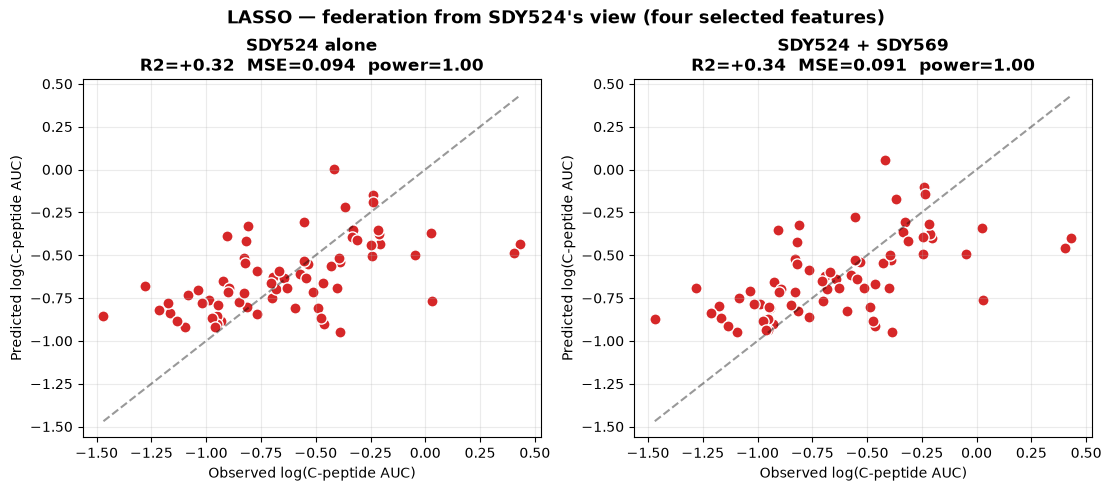

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)
lo = min(y4.min(), np.nanmin(solo), np.nanmin(fed))
hi = max(y4.max(), np.nanmax(solo), np.nanmax(fed))
panels = [(solo, THIS + " alone", mse_s, r2_s, pw_s),
          (fed, THIS + " + " + "+".join(PARTNERS), mse_f, r2_f, pw_f)]
for ax, (pred, title, mse, r2, pw) in zip(axes, panels):
    ax.scatter(y4, pred, c="#d62728", s=65, edgecolor="white")
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.4)
    ax.set_xlabel("Observed log(C-peptide AUC)")
    ax.set_ylabel("Predicted log(C-peptide AUC)")
    ax.set_title(f"{title}\nR2={r2:+.2f}  MSE={mse:.3f}  power={pw:.2f}", fontweight="bold")
    ax.grid(alpha=0.25)
fig.suptitle("LASSO — federation from " + THIS + "'s view (four selected features)",
             fontsize=13, fontweight="bold")
fig.savefig(f"figures/LASSO_{THIS}_federated.pdf", dpi=300)
fig.savefig(f"figures/LASSO_{THIS}_federated.png", dpi=220)
plt.show()


## 5. Output

`figures/LASSO_SDY524_federated.pdf` / `.png` — SDY524 solo vs
federated on the four LASSO-selected features, with R², MSE, and achieved power.
This is the within-institution view of what federation buys SDY524: the partner
coefficients were read from disk; no
subject-level data crossed institutions.
